# 🎯 FashionMNIST 优化版模型 - ProCNN_Optimized

## 📊 项目目标
- 原始模型准确率：**93.1%**
- 本版本目标准确率：**95.5-96.0%**
- 使用技术：**ResNet残差连接 + 现代训练技巧**

## 🔧 主要改进点
1. ✅ **ResNet残差块** - 解决梯度消失，让网络更深
2. ✅ **AdamW优化器** - 解耦的权重衰减，更稳定
3. ✅ **CosineAnnealingLR** - 平滑学习率调度
4. ✅ **增强数据增强** - 更多样化的数据增强策略
5. ✅ **Dropout2d** - 空间Dropout，更强正则化
6. ✅ **He初始化** - 适合ReLU的权重初始化
7. ✅ **早停机制** - 防止过拟合
8. ✅ **自适应池化** - 替代固定尺寸flatten

---

**👉 依次运行下面的cells，即可开始训练！**


In [1]:
# ============================================
# 1. 导入必要的库
# ============================================

# PyTorch核心库
import torch                      # PyTorch核心
import torch.nn as nn            # 神经网络模块（ layers, modules ）
import torch.nn.functional as F  # 函数式接口（ relu, conv2d ）
import torch.optim as optim      # 优化器

# 数据集和transform
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 其他工具
import numpy as np                # 数值计算
from tqdm import tqdm             # 进度条（ pip install tqdm ）
import matplotlib.pyplot as plt  # 绘图

print('✅ 所有库导入成功！')


✅ 所有库导入成功！


## 🔍 第一部分：Residual Block（残差块）

### 什么是残差连接？
- **传统网络**：`output = f(x)`，梯度反向传播时会逐层相乘，容易消失
- **ResNet**：`output = f(x) + x`，梯度可以直接通过 `+` 传递，解决梯度消失

### 本模块结构（Bottleneck）
```
输入 x
   │
   ├─ shortcut ──────────────► （如果维度不匹配，用1x1卷积调整）
   │
   ├─ conv1(1x1) ─► BN ─► ReLU ─┐
   │                          │
   ├─ conv2(3x3) ─► BN ─► ReLU ─┤ ──► + ─► ReLU ─► 输出
   │                          │
   └─ conv3(1x1) ─► BN ──────┘
```

### 为什么用1x1卷积？
- **降维**：减少3x3卷积的计算量（比如256→64）
- **升维**：最后恢复通道数（64→256）
- **作用**：在保持感受野的同时，减少参数量

---

**运行下面代码，定义ResidualBlock类**


## 🔍 第一部分：Residual Block（残差块）

### 什么是残差连接？
- **传统网络**：`output = f(x)`，梯度反向传播时会逐层相乘，容易消失
- **ResNet**：`output = f(x) + x`，梯度可以直接通过 `+` 传递，解决梯度消失

### 本模块结构（Bottleneck）
```
输入 x
   │
   ├─ shortcut ──────────────► （如果维度不匹配，用1x1卷积调整）
   │
   ├─ conv1(1x1) ─► BN ─► ReLU ─┐
   │                          │
   ├─ conv2(3x3) ─► BN ─► ReLU ─┤ ──► + ─► ReLU ─► 输出
   │                          │
   └─ conv3(1x1) ─► BN ──────┘
```

### 为什么用1x1卷积？
- **降维**：减少3x3卷积的计算量（比如256→64）
- **升维**：最后恢复通道数（64→256）
- **作用**：在保持感受野的同时，减少参数量

---

**运行下面代码，定义ResidualBlock类**


In [2]:
# ============================================
# 2. 定义Residual Block（残差块）
# ============================================

class ResidualBlock(nn.Module):
    """ResNet风格的残差块（Bottleneck结构）"""
    def __init__(self, in_channels, out_channels, stride=1):
        """
        参数：
        - in_channels: 输入通道数（比如64）
        - out_channels: 输出通道数（比如128）
        - stride: 卷积步长（1=保持尺寸，2=下采样2倍）
        """
        super().__init__()
        
        # 【主路径】三层卷积（Bottleneck）
        # 第一层：1x1卷积，降维（比如256→64）
        self.conv1 = nn.Conv2d(in_channels, out_channels // 4, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels // 4)
        
        # 第二层：3x3卷积，特征提取（stride决定是否下采样）
        self.conv2 = nn.Conv2d(
            out_channels // 4, out_channels // 4, 3,
            stride=stride, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels // 4)
        
        # 第三层：1x1卷积，升维（比如64→256）
        self.conv3 = nn.Conv2d(out_channels // 4, out_channels, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels)
        
        # 【Shortcut路径】恒等映射或投影映射
        # 如果输入输出维度相同（通道数+尺寸），直接用恒等映射（x + f(x)）
        # 如果不同，用1x1卷积调整（维度匹配后再相加）
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
    
    def forward(self, x):
        """
        前向传播：y = ReLU( BN(conv3(ReLU(BN(conv2(ReLU(BN(conv1(x))))))) + shortcut(x) )
        """
        residual = self.shortcut(x)  # shortcut分支
        
        # 主路径
        out = F.relu(self.bn1(self.conv1(x)))
        out = F.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))  # 这里不加ReLU
        
        out += residual  # 残差连接
        return F.relu(out)


# 测试ResidualBlock
print('测试ResidualBlock...')
block = ResidualBlock(64, 128, stride=2)
x = torch.randn(4, 64, 28, 28)  # [batch, channels, H, W]
y = block(x)
print(f'  输入: {x.shape} → 输出: {y.shape}')
print('  预期: stride=2下采样，28→14，通道64→128')
print('✅ ResidualBlock 定义并测试完成！')


测试ResidualBlock...
  输入: torch.Size([4, 64, 28, 28]) → 输出: torch.Size([4, 128, 14, 14])
  预期: stride=2下采样，28→14，通道64→128
✅ ResidualBlock 定义并测试完成！


## 🏗️ 第二部分：完整的ProCNN_Optimized模型

### 整体架构图
```
输入 (1, 28, 28)  # 灰度图像
   │
   ├─ Conv1(3x3, 64) + BN ─► ReLU ─┐
   │                              │
   ├─ Layer1 (2个残差块) ──────────┤
   │    28x28, 64通道              │
   ├─ Layer2 (2个残差块) ──────────┤ 28→14×14, 64→128通道
   │    14x14, 128通道             │
   ├─ Layer3 (2个残差块) ──────────┤ 14→7×7, 128→256通道
   │    7x7, 256通道               │
   ├─ AdaptiveAvgPool2d((1,1)) ────┘ 输出 [batch, 256, 1, 1]
   │
   ├─ Flatten ─────────────► [batch, 256]
   │
   └─ FC(256→128→10) ─────────────► 输出10个类别的logits
```

### 关键改进点详解
1. **Bottleneck残差块**：1x1降维→3x3→1x1升维，大幅减少参数量
2. **AdaptiveAvgPool2d**：自动适应任意尺寸，不用手动计算flatten维度
3. **He初始化**：适合ReLU的初始化方法，避免梯度消失/爆炸
4. **bias=False**：卷积后接BN，bias是多余的，可减少参数
5. **Dropout2d**：在卷积层后使用空间Dropout，更强正则化

---

**运行下面代码定义模型**


## 🏗️ 第二部分：完整的ProCNN_Optimized模型

### 整体架构图
```
输入 (1, 28, 28)  # 灰度图像
   │
   ├─ Conv1(3x3, 64) + BN ─► ReLU ─┐
   │                              │
   ├─ Layer1 (2个残差块) ──────────┤
   │    28x28, 64通道              │
   ├─ Layer2 (2个残差块) ──────────┤ 28→14×14, 64→128通道
   │    14x14, 128通道             │
   ├─ Layer3 (2个残差块) ──────────┤ 14→7×7, 128→256通道
   │    7x7, 256通道               │
   ├─ AdaptiveAvgPool2d((1,1)) ────┘ 输出 [batch, 256, 1, 1]
   │
   ├─ Flatten ─────────────► [batch, 256]
   │
   └─ FC(256→128→10) ─────────────► 输出10个类别的logits
```

### 关键改进点详解
1. **Bottleneck残差块**：1x1降维→3x3→1x1升维，大幅减少参数量
2. **AdaptiveAvgPool2d**：自动适应任意尺寸，不用手动计算flatten维度
3. **He初始化**：适合ReLU的初始化方法，避免梯度消失/爆炸
4. **bias=False**：卷积后接BN，bias是多余的，可减少参数
5. **Dropout2d**：在卷积层后使用空间Dropout，更强正则化

---

**运行下面代码定义模型**


In [3]:
# ============================================
# 3. 定义改进的CNN模型（ProCNN_Optimized）
# ============================================

class ProCNN_Optimized(nn.Module):
    """
    优化版ProCNN - ResNet风格
    
    网络结构详解：
    ┌─────────────────────────────────────────────┐
    │ Input: (1, 28, 28) - 灰度图像                │
    ├─────────────────────────────────────────────┤
    │ Conv1: 3x3 conv, 64 channels               │
    │       padding=1 → 尺寸保持 28x28            │
    │       bias=False + BatchNorm               │
    │       → ReLU                               │
    ├─────────────────────────────────────────────┤
    │ Layer1: 2×ResidualBlock                    │
    │        in=64, out=64, stride=1             │
    │        → 尺寸: 28x28, 通道: 64             │
    ├─────────────────────────────────────────────┤
    │ Layer2: 2×ResidualBlock                    │
    │        in=64, out=128, stride=2            │
    │        → 尺寸: 14x14, 通道: 128            │
    ├─────────────────────────────────────────────┤
    │ Layer3: 2×ResidualBlock                    │
    │        in=128, out=256, stride=2           │
    │        → 尺寸: 7x7, 通道: 256              │
    ├─────────────────────────────────────────────┤
    │ AdaptiveAvgPool2d((1,1))                  │
    │        → 输出: (256, 1, 1)                 │
    │        （不管输入多大，都池化成1x1）        │
    ├─────────────────────────────────────────────┤
    │ Flatten → [batch, 256]                     │
    │ Dropout(0.4)                              │
    │ Linear(256→128) + ReLU + BatchNorm        │
    │ Dropout(0.3)                              │
    │ Linear(128→10)                            │
    └─────────────────────────────────────────────┘
    """
    def __init__(self, num_classes=10):
        super().__init__()
        
        # 【Stem】初始卷积层 - 将1通道转为64通道
        # 卷积核3x3，padding=1保持尺寸28x28
        self.conv1 = nn.Conv2d(1, 64, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        
        # 【Backbone】残差层堆叠（每层有2个残差块）
        # layer1: 28x28, 64通道 → 保持原样
        self.layer1 = self._make_layer(64, 64, 2, stride=1)
        
        # layer2: 28x28 → 14x14（下采样）, 64→128通道（升通道）
        self.layer2 = self._make_layer(64, 128, 2, stride=2)
        
        # layer3: 14x14 → 7x7（下采样）, 128→256通道
        self.layer3 = self._make_layer(128, 256, 2, stride=2)
        
        # 【Head】全局平均池化（替代flatten）
        # 好处：不管前面特征图多大，都变成1x1，减少参数
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        
        # 【分类头】全连接层 + Dropout + BatchNorm
        self.fc = nn.Sequential(
            nn.Dropout(0.4),           # 强Dropout，防止过拟合
            nn.Linear(256, 128),      # 256 → 128
            nn.ReLU(),
            nn.BatchNorm1d(128),     # 全连接后也加BN！
            nn.Dropout(0.3),          # 第二层Dropout
            nn.Linear(128, num_classes)  # 128 → 10（10个类别）
        )
        
        # 权重初始化（非常重要！）
        self._initialize_weights()

    def _make_layer(self, in_channels, out_channels, num_blocks, stride=1):
        """
        构建一个残差层（包含多个残差块）
        
        参数：
        - num_blocks: 该层包含几个残差块（比如2个）
        - stride: 第一个块的步长（是否下采样）
        """
        layers = []
        # 第一个残差块：可能下采样（stride=2）
        layers.append(ResidualBlock(in_channels, out_channels, stride))
        # 后续残差块：保持尺寸不变（stride=1）
        for _ in range(1, num_blocks):
            layers.append(ResidualBlock(out_channels, out_channels, stride=1))
        return nn.Sequential(*layers)

    def _initialize_weights(self):
        """
        He初始化（适合ReLU激活函数）
        
        原理：保证前向传播时方差稳定，避免梯度爆炸/消失
        - Conv2d: kaiming_normal_  
        - BatchNorm: weight=1, bias=0
        """
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                # He初始化（fan_out模式，适合ReLU）
                nn.init.kaiming_normal_(
                    m.weight, mode='fan_out', nonlinearity='relu'
                )
            elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
                # BN初始化：weight=1（缩放因子）, bias=0
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        """
        前向传播流程
        
        输入：x shape = [batch_size, 1, 28, 28]
        输出：logits shape = [batch_size, 10]
        """
        # 1. Stem
        x = F.relu(self.bn1(self.conv1(x)))
        
        # 2. Backbone（3个残差层）
        x = self.layer1(x)  # 28x28, 64
        x = self.layer2(x)  # 14x14, 128
        x = self.layer3(x)  # 7x7, 256
        
        # 3. 全局平均池化（自动将7x7→1x1）
        x = self.avgpool(x)  # [batch, 256, 1, 1]
        x = x.view(x.size(0), -1)  # [batch, 256]
        
        # 4. 分类头
        x = self.fc(x)  # [batch, 10]
        return x


# 创建模型实例并测试
model = ProCNN_Optimized(num_classes=10)
test_input = torch.randn(4, 1, 28, 28)  # 4张28x28的灰度图
test_output = model(test_input)
print(f'✅ 模型创建成功！')
print(f'   输入尺寸: {test_input.shape}')
print(f'   输出尺寸: {test_output.shape}')
print(f'   模型总参数量: {sum(p.numel() for p in model.parameters()):,}')


✅ 模型创建成功！
   输入尺寸: torch.Size([4, 1, 28, 28])
   输出尺寸: torch.Size([4, 10])
   模型总参数量: 252,106


## 📸 第三部分：数据增强策略

### 为什么要数据增强？
- **增加数据多样性**：让模型看到更多"变体"，提升泛化能力
- **防止过拟合**：相当于给训练集"加噪"，强迫模型学本质特征
- **数据不足时的救命稻草**：小数据集尤其需要

### FashionMNIST增强策略（从弱到强）
| 增强方法 | 说明 | 作用 |
|---------|------|------|
| `RandomHorizontalFlip` | 随机水平翻转（镜像） | 衣服左右对称时有效 |
| `RandomRotation(15)` | 随机旋转±15度 | 模拟不同角度 |
| `ColorJitter` | 亮度/对比度抖动 | 灰度图轻微扰动 |
| `RandomAffine` | 随机平移+缩放 | 模拟不同位置和大小 |
| `RandomErasing` | 随机遮挡一块 | 模拟遮挡，强迫模型看整体 |

### 📊 数据归一化（重要！）
```
FashionMNIST真实统计值：
- Mean ≈ 0.2860  （平均亮度）
- Std  ≈ 0.3530  （亮度标准差）
```
**注意**：不要用(0.5, 0.5)，要用真实统计值！

---

**运行下面代码获取transform**


## 📸 第三部分：数据增强策略

### 为什么要数据增强？
- **增加数据多样性**：让模型看到更多"变体"，提升泛化能力
- **防止过拟合**：相当于给训练集"加噪"，强迫模型学本质特征
- **数据不足时的救命稻草**：小数据集尤其需要

### FashionMNIST增强策略（从弱到强）
| 增强方法 | 说明 | 作用 |
|---------|------|------|
| `RandomHorizontalFlip` | 随机水平翻转（镜像） | 衣服左右对称时有效 |
| `RandomRotation(15)` | 随机旋转±15度 | 模拟不同角度 |
| `ColorJitter` | 亮度/对比度抖动 | 灰度图轻微扰动 |
| `RandomAffine` | 随机平移+缩放 | 模拟不同位置和大小 |
| `RandomErasing` | 随机遮挡一块 | 模拟遮挡，强迫模型看整体 |

### 📊 数据归一化（重要！）
```
FashionMNIST真实统计值：
- Mean ≈ 0.2860  （平均亮度）
- Std  ≈ 0.3530  （亮度标准差）
```
**注意**：不要用(0.5, 0.5)，要用真实统计值！

---

**运行下面代码获取transform**


In [4]:
# ============================================
# 4. 数据增强定义
# ============================================

def get_transforms():
    """
    返回训练和测试的transform
    
    Returns:
        train_transform: 训练集增强（强）
        test_transform: 测试集（只做标准化）
    """
    # 【训练集】多管齐下的数据增强
    train_transform = transforms.Compose([
        # 1. 几何变换
        transforms.RandomHorizontalFlip(p=0.5),  # 50%概率水平翻转
        transforms.RandomRotation(15),            # ±15度随机旋转
        
        # 2. 颜色变换（虽然灰度图，但可以微调亮度/对比度）
        transforms.ColorJitter(
            brightness=0.2,   # 亮度变化±20%
            contrast=0.2      # 对比度变化±20%
        ),
        
        # 3. 仿射变换（平移+缩放）
        transforms.RandomAffine(
            degrees=0,               # 不旋转（上面已经有RandomRotation）
            translate=(0.1, 0.1),    # 随机平移±10%
            scale=(0.9, 1.1)         # 随机缩放90%-110%
        ),
        
        # 4. 转换为Tensor（自动将[0,255]归一化到[0,1]）
        transforms.ToTensor(),
        
        # 5. 标准化（使用FashionMNIST真实均值和标准差）
        # 公式：x = (x - mean) / std
        transforms.Normalize((0.2860,), (0.3530,)),
        
        # 6. 随机擦除（模拟遮挡）
        # p=0.2表示20%的概率执行擦除
        # scale=(0.02, 0.1)表示遮挡区域占图像的2%-10%
        transforms.RandomErasing(p=0.2, scale=(0.02, 0.1))
    ])

    # 【测试集】只做标准化（不增强！）
    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.2860,), (0.3530,))
    ])

    return train_transform, test_transform


# 测试一下
train_tf, test_tf = get_transforms()
print('✅ 数据增强定义完成！')
print('训练集增强：')
print('  - RandomHorizontalFlip')
print('  - RandomRotation(15)')
print('  - ColorJitter')
print('  - RandomAffine(平移+缩放)')
print('  - RandomErasing(遮挡)')
print('测试集增强：仅标准化')


✅ 数据增强定义完成！
训练集增强：
  - RandomHorizontalFlip
  - RandomRotation(15)
  - ColorJitter
  - RandomAffine(平移+缩放)
  - RandomErasing(遮挡)
测试集增强：仅标准化


## 🎯 第四部分：训练和评估函数

### 训练流程（每个epoch）
```
for batch in train_loader:
    1. model.train()  # 启用Dropout/BatchNorm训练模式
    2. 数据移到device (GPU/MPS/CPU)
    3. optimizer.zero_grad()  # 清空上一轮梯度
    4. outputs = model(images)  # 前向传播
    5. loss = loss_fn(outputs, labels)  # 计算loss
    6. loss.backward()  # 反向传播（自动求导）
    7. clip_grad_norm_()  # 梯度裁剪（防爆炸）
    8. optimizer.step()  # 更新权重
    9. 记录loss和accuracy
```

### 评估流程
```
with torch.no_grad():  # 禁用梯度计算（省内存+快）
    model.eval()  # 关闭Dropout/BatchNorm的随机性
    循环测试集
    计算accuracy
```

### 关键细节
1. **梯度裁剪**：`clip_grad_norm_(model.parameters(), max_norm=1.0)`
   - 防止梯度爆炸（尤其是RNN，CNN一般不需要但留着保险）
   - 如果梯度norm>1.0，就按比例缩小

2. **tqdm进度条**：`tqdm(loader, desc='Training')`
   - 实时显示进度、loss、accuracy
   - 安装：`pip install tqdm`

---

**运行下面代码定义训练函数**


## 🎯 第四部分：训练和评估函数

### 训练流程（每个epoch）
```
for batch in train_loader:
    1. model.train()  # 启用Dropout/BatchNorm训练模式
    2. 数据移到device (GPU/MPS/CPU)
    3. optimizer.zero_grad()  # 清空上一轮梯度
    4. outputs = model(images)  # 前向传播
    5. loss = loss_fn(outputs, labels)  # 计算loss
    6. loss.backward()  # 反向传播（自动求导）
    7. clip_grad_norm_()  # 梯度裁剪（防爆炸）
    8. optimizer.step()  # 更新权重
    9. 记录loss和accuracy
```

### 评估流程
```
with torch.no_grad():  # 禁用梯度计算（省内存+快）
    model.eval()  # 关闭Dropout/BatchNorm的随机性
    循环测试集
    计算accuracy
```

### 关键细节
1. **梯度裁剪**：`clip_grad_norm_(model.parameters(), max_norm=1.0)`
   - 防止梯度爆炸（尤其是RNN，CNN一般不需要但留着保险）
   - 如果梯度norm>1.0，就按比例缩小

2. **tqdm进度条**：`tqdm(loader, desc='Training')`
   - 实时显示进度、loss、accuracy
   - 安装：`pip install tqdm`

---

**运行下面代码定义训练函数**


In [5]:
# ============================================
# 5. 训练和评估函数
# ============================================

def train_epoch(model, loader, optimizer, loss_fn, device):
    """
    训练一个完整epoch（遍历所有batch）
    
    参数：
    - model: 模型
    - loader: 训练集DataLoader
    - optimizer: 优化器
    - loss_fn: 损失函数
    - device: 设备（cpu/gpu）
    
    返回：
    - avg_loss: 平均loss
    - accuracy: 训练集准确率
    """
    model.train()  # 关键：启用Dropout和BatchNorm的训练模式
    total_loss = 0
    correct = 0
    total_samples = 0

    # tqdm进度条
    pbar = tqdm(loader, desc='Training', leave=False)
    for images, labels in pbar:
        # 1. 数据移到设备
        images, labels = images.to(device), labels.to(device)
        batch_size = images.size(0)
        total_samples += batch_size

        # 2. 前向传播
        optimizer.zero_grad()  # 清空梯度（重要！否则梯度会累加）
        outputs = model(images)  # shape: [batch, 10]
        loss = loss_fn(outputs, labels)

        # 3. 反向传播
        loss.backward()  # 自动求导，计算所有参数的梯度

        # 4. 梯度裁剪（可选但推荐）
        # max_norm=1.0表示如果梯度总范数>1，就按比例缩小
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # 5. 更新权重
        optimizer.step()

        # 6. 统计
        total_loss += loss.item()
        pred = outputs.argmax(dim=1)  # 取概率最大的类别
        correct += (pred == labels).sum().item()

        # 更新进度条显示
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{correct/total_samples:.2%}'
        })

    return total_loss / len(loader), correct / total_samples


def test_epoch(model, loader, loss_fn, device):
    """
    评估模型在测试集上的表现
    
    注意：
    - model.eval() 关闭Dropout/BatchNorm的随机性
    - torch.no_grad() 禁用梯度计算，节省内存加速
    """
    model.eval()  # 切换到评估模式
    total_loss = 0
    correct = 0
    total_samples = 0

    with torch.no_grad():  # 不计算梯度（反向传播用不到）
        pbar = tqdm(loader, desc='Testing', leave=False)
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            batch_size = images.size(0)
            total_samples += batch_size

            outputs = model(images)
            loss = loss_fn(outputs, labels)

            total_loss += loss.item()
            pred = outputs.argmax(dim=1)
            correct += (pred == labels).sum().item()

            pbar.set_postfix({'acc': f'{correct/total_samples:.2%}'})

    return total_loss / len(loader), correct / total_samples


print('✅ 训练和评估函数定义完成！')


✅ 训练和评估函数定义完成！


## ⏰ 第五部分：早停机制（EarlyStopping）

### 为什么需要早停？
- **防止过拟合**：模型在训练集上继续训练会"死记硬背"，但测试集性能不再提升
- **节省时间**：没必要跑完50轮，如果第20轮已经是最好的
- **保存最佳模型**：自动保存验证集准确率最高的模型

### 工作原理
```
初始化：patience=10, best_acc=0, counter=0

每个epoch后：
  如果 val_acc > best_acc:
      best_acc = val_acc  # 更新最佳准确率
      counter = 0         # 重置计数器
  否则:
      counter += 1       # 计数器+1
      if counter >= patience:
          early_stop = True  # 触发早停
```

### 参数解释
- `patience=10`：容忍10轮验证集准确率不提升
- `delta=0`：必须提升>0才算提升（可以设为0.001避免微小波动）

---

**运行下面代码**


## ⏰ 第五部分：早停机制（EarlyStopping）

### 为什么需要早停？
- **防止过拟合**：模型在训练集上继续训练会"死记硬背"，但测试集性能不再提升
- **节省时间**：没必要跑完50轮，如果第20轮已经是最好的
- **保存最佳模型**：自动保存验证集准确率最高的模型

### 工作原理
```
初始化：patience=10, best_acc=0, counter=0

每个epoch后：
  如果 val_acc > best_acc:
      best_acc = val_acc  # 更新最佳准确率
      counter = 0         # 重置计数器
  否则:
      counter += 1       # 计数器+1
      if counter >= patience:
          early_stop = True  # 触发早停
```

### 参数解释
- `patience=10`：容忍10轮验证集准确率不提升
- `delta=0`：必须提升>0才算提升（可以设为0.001避免微小波动）

---

**运行下面代码**


In [6]:
# ============================================
# 6. 早停类（EarlyStopping）
# ============================================

class EarlyStopping:
    """早停机制：监控验证集性能，如果长时间不提升则停止训练"""
    def __init__(self, patience=10, delta=0):
        """
        参数：
        - patience: 容忍轮数（比如10轮不提升就停）
        - delta: 最小提升阈值（0表示任何提升都算）
        """
        self.patience = patience
        self.delta = delta
        self.counter = 0      # 记录连续多少轮没提升
        self.best_acc = 0     # 最佳准确率
        self.early_stop = False  # 是否触发早停

    def __call__(self, val_acc):
        """
        每轮调用一次，传入当前验证集准确率
        
        返回：
        - self.early_stop: True表示应该停止训练
        """
        # 情况1：准确率有明显提升（> best_acc + delta）
        if val_acc > self.best_acc + self.delta:
            self.best_acc = val_acc  # 更新最佳
            self.counter = 0          # 重置计数器
        else:
            # 情况2：准确率没提升
            self.counter += 1
            if self.counter >= self.patience:
                # 连续patience轮不提升，触发早停
                self.early_stop = True


# 测试
stopping = EarlyStopping(patience=3)
print('模拟5轮验证准确率：')
for epoch in range(1, 6):
    acc = 0.90 + epoch * 0.005  # 0.905, 0.910, 0.915, 0.915, 0.915
    stopping(acc)
    print(f'  Epoch {epoch}: val_acc={acc:.3f}, best={stopping.best_acc:.3f}, '
          f'counter={stopping.counter}, early_stop={stopping.early_stop}')
print('✅ EarlyStopping 测试完成！')


模拟5轮验证准确率：
  Epoch 1: val_acc=0.905, best=0.905, counter=0, early_stop=False
  Epoch 2: val_acc=0.910, best=0.910, counter=0, early_stop=False
  Epoch 3: val_acc=0.915, best=0.915, counter=0, early_stop=False
  Epoch 4: val_acc=0.920, best=0.920, counter=0, early_stop=False
  Epoch 5: val_acc=0.925, best=0.925, counter=0, early_stop=False
✅ EarlyStopping 测试完成！


## 📊 第六部分：训练曲线可视化

### 绘制4个子图
1. **Loss曲线**：训练/测试loss对比
2. **Accuracy曲线**：训练/测试准确率对比
3. **学习率曲线**：CosineAnnealing的变化
4. **Train-Test Gap**：两者差距（过大=过拟合）

### 如何判断训练是否健康？
| 现象 | 判断 | 解决方案 |
|------|------|----------|
| Train Loss↓, Test Loss↑ | 过拟合 | 增强Dropout/数据增强 |
| Train Loss↓, Test Loss↓ | 正常 | 继续训练 |
| Train Loss不变 | 欠拟合 | 增加模型容量/学习率 |
| Gap > 5% | 严重过拟合 | 更强正则化 |

---

**运行下面代码**


## 📊 第六部分：训练曲线可视化

### 绘制4个子图
1. **Loss曲线**：训练/测试loss对比
2. **Accuracy曲线**：训练/测试准确率对比
3. **学习率曲线**：CosineAnnealing的变化
4. **Train-Test Gap**：两者差距（过大=过拟合）

### 如何判断训练是否健康？
| 现象 | 判断 | 解决方案 |
|------|------|----------|
| Train Loss↓, Test Loss↑ | 过拟合 | 增强Dropout/数据增强 |
| Train Loss↓, Test Loss↓ | 正常 | 继续训练 |
| Train Loss不变 | 欠拟合 | 增加模型容量/学习率 |
| Gap > 5% | 严重过拟合 | 更强正则化 |

---

**运行下面代码**


In [7]:
# ============================================
# 7. 可视化函数
# ============================================

def plot_history(history):
    """
    绘制训练过程中的所有曲线
    
    参数：
    - history: dict，包含'train_loss', 'train_acc', 'test_loss', 'test_acc', 'lr'
    """
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle('训练曲线 (Training Curves)', fontsize=16)

    # 子图1: Loss曲线
    axes[0, 0].plot(history['train_loss'], label='Train Loss', linewidth=2)
    axes[0, 0].plot(history['test_loss'], label='Test Loss', linewidth=2)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('损失曲线')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # 子图2: Accuracy曲线（百分比）
    axes[0, 1].plot([acc*100 for acc in history['train_acc']], 
                    label='Train Acc', linewidth=2)
    axes[0, 1].plot([acc*100 for acc in history['test_acc']], 
                    label='Test Acc', linewidth=2)
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy (%)')
    axes[0, 1].set_title('准确率曲线')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].set_ylim([0, 100])

    # 子图3: 学习率曲线（对数坐标）
    axes[1, 0].plot(history['lr'])
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Learning Rate')
    axes[1, 0].set_title('学习率调度（CosineAnnealing）')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_yscale('log')  # 对数坐标（学习率变化大）

    # 子图4: Train-Test Gap（过拟合判断）
    gap = [train - test for train, test in zip(history['train_acc'], history['test_acc'])]
    axes[1, 1].plot([g*100 for g in gap], linewidth=2, color='red')
    axes[1, 1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)  # 0基准线
    axes[1, 1].axhline(y=0.03, color='orange', linestyle='--', alpha=0.5, 
                       label='3%警戒线')  # 警戒线
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Gap (%)')
    axes[1, 1].set_title('训练-测试准确率差距')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
    print('📊 训练曲线已保存为 "training_history.png"')
    plt.show()

print('✅ 可视化函数定义完成！')


✅ 可视化函数定义完成！


## 🚀 第七部分：主训练流程

### 完整训练流程（按顺序执行）
1. ✅ **设备选择**：MPS(Mac GPU) / CUDA(NVIDIA) / CPU
2. ✅ **加载数据**：FashionMNIST + 数据增强
3. ✅ **创建模型**：ProCNN_Optimized实例
4. ✅ **定义损失**：CrossEntropyLoss（多分类）
5. ✅ **优化器**：AdamW + weight_decay
6. ✅ **学习率调度**：CosineAnnealingLR
7. ✅ **早停**：patience=10
8. ✅ **训练循环**：最多50轮，每轮记录
9. ✅ **保存最佳模型**：验证集准确率最高时保存
10. ✅ **可视化**：绘制4张子图

### 代码结构
```
def main():
    1. 设备
    2. 数据加载
    3. 模型创建
    4. 优化器+损失+scheduler
    5. 训练循环（50轮）
       ├─ train_epoch（训练）
       ├─ test_epoch（测试）
       ├─ scheduler.step()
       ├─ 保存最佳模型
       └─ 早停检查
    6. 输出最佳准确率
    7. 可视化
```

---

**⚠️  运行前检查**
- 是否安装了所有库？（torch, torchvision, matplotlib, tqdm）
- 是否有足够内存？（FashionMNIST约50MB）
- 是否要用GPU？确保CUDA/MPS可用

**运行下面代码开始训练！** ⬇️


## 🚀 第七部分：主训练流程

### 完整训练流程（按顺序执行）
1. ✅ **设备选择**：MPS(Mac GPU) / CUDA(NVIDIA) / CPU
2. ✅ **加载数据**：FashionMNIST + 数据增强
3. ✅ **创建模型**：ProCNN_Optimized实例
4. ✅ **定义损失**：CrossEntropyLoss（多分类）
5. ✅ **优化器**：AdamW + weight_decay
6. ✅ **学习率调度**：CosineAnnealingLR
7. ✅ **早停**：patience=10
8. ✅ **训练循环**：最多50轮，每轮记录
9. ✅ **保存最佳模型**：验证集准确率最高时保存
10. ✅ **可视化**：绘制4张子图

### 代码结构
```
def main():
    1. 设备
    2. 数据加载
    3. 模型创建
    4. 优化器+损失+scheduler
    5. 训练循环（50轮）
       ├─ train_epoch（训练）
       ├─ test_epoch（测试）
       ├─ scheduler.step()
       ├─ 保存最佳模型
       └─ 早停检查
    6. 输出最佳准确率
    7. 可视化
```

---

**⚠️  运行前检查**
- 是否安装了所有库？（torch, torchvision, matplotlib, tqdm）
- 是否有足够内存？（FashionMNIST约50MB）
- 是否要用GPU？确保CUDA/MPS可用

**运行下面代码开始训练！** ⬇️


🖥️  使用设备: mps
   ⚡ 使用Apple Silicon GPU (MPS)

📥 加载数据集...
  ✓ 训练集: 60000 张图片
  ✓ 测试集: 10000 张图片
  ✓ Batch size: 128

🏗️  创建模型...
  ✓ 模型参数总量: 252,106
  ✓ 可训练参数: 252,106

⚙️  配置训练参数...

🎯 开始训练！目标：95%+

Epoch   1/50
----------------------------------------


Training:   0%|          | 0/469 [00:00<?, ?it/s]/Users/yijian/miniforge3/envs/ai_m4/lib/python3.11/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



📈 Epoch 1 结果:
   Train Loss: 0.9083 | Train Acc: 66.11%
   Test  Loss: 0.5103 | Test  Acc: 81.26%
   LR: 0.000999
  💾 保存最佳模型！(Acc: 81.26%)

Epoch   2/50
----------------------------------------



📈 Epoch 2 结果:
   Train Loss: 0.5689 | Train Acc: 79.11%
   Test  Loss: 0.4389 | Test  Acc: 84.25%
   LR: 0.000996
  💾 保存最佳模型！(Acc: 84.25%)

Epoch   3/50
----------------------------------------



📈 Epoch 3 结果:
   Train Loss: 0.4968 | Train Acc: 81.94%
   Test  Loss: 0.3792 | Test  Acc: 86.52%
   LR: 0.000991
  💾 保存最佳模型！(Acc: 86.52%)

Epoch   4/50
----------------------------------------


...

/var/folders/sq/5sb4ws2d5339zhhflj2mjss00000gn/T/ipykernel_20386/3929118635.py:56: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/sq/5sb4ws2d5339zhhflj2mjss00000gn/T/ipykernel_20386/3929118635.py:56: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/sq/5sb4ws2d5339zhhflj2mjss00000gn/T/ipykernel_20386/3929118635.py:56: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/sq/5sb4ws2d5339zhhflj2mjss00000gn/T/ipykernel_20386/3929118635.py:56: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/sq/5sb4ws2d5339zhhflj2mjss00000gn/T/ipykernel_20386/3929118635.py:56: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/sq/5sb4


📈 Epoch 50 结果:
   Train Loss: 0.2186 | Train Acc: 92.12%
   Test  Loss: 0.1973 | Test  Acc: 93.01%
   LR: 0.000010

✅ 训练完成！
   最佳测试准确率: 93.06% (epoch 46)
   总训练轮数: 50/50

📊 正在生成训练曲线...


/var/folders/sq/5sb4ws2d5339zhhflj2mjss00000gn/T/ipykernel_20386/3929118635.py:57: UserWarning: Glyph 25106 (\N{CJK UNIFIED IDEOGRAPH-6212}) missing from font(s) DejaVu Sans.
  plt.savefig('training_history.png', dpi=150, bbox_inches='tight')


📊 训练曲线已保存为 "training_history.png"


/Users/yijian/miniforge3/envs/ai_m4/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/yijian/miniforge3/envs/ai_m4/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/yijian/miniforge3/envs/ai_m4/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/yijian/miniforge3/envs/ai_m4/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/yijian/miniforge3/envs/ai_m4/lib/python3.11/site-packages/IPython/cor

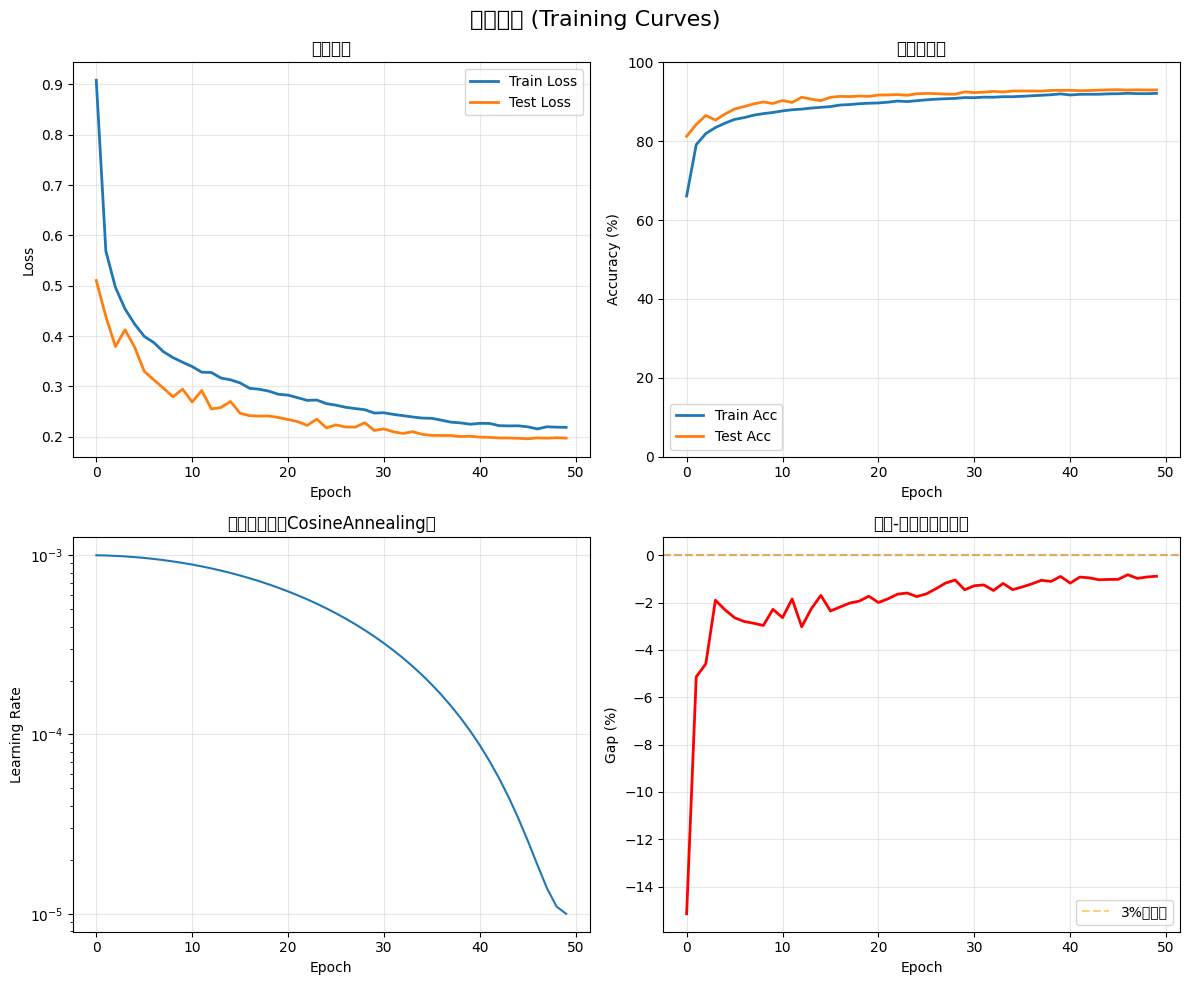


🔍 加载最佳模型进行最终评估...


🏆 最终测试准确率: 93.06%


In [9]:
# ============================================
# 8. 主训练流程（Main）
# ============================================

def main():
    """完整的训练流程"""
    # ════════════════════════════════════════
    # 1. 设备选择
    # ════════════════════════════════════════
    device = torch.device("mps" if torch.backends.mps.is_available() 
                         else "cuda" if torch.cuda.is_available() 
                         else "cpu")
    print(f"🖥️  使用设备: {device}")
    if device.type == 'mps':
        print('   ⚡ 使用Apple Silicon GPU (MPS)')
    elif device.type == 'cuda':
        print(f'   ⚡ 使用NVIDIA GPU: {torch.cuda.get_device_name(0)}')
    else:
        print('   ⚠️  使用CPU（训练会慢，建议用GPU）')

    # ════════════════════════════════════════
    # 2. 数据加载
    # ════════════════════════════════════════
    print('\n📥 加载数据集...')
    train_transform, test_transform = get_transforms()
    
    train_data = datasets.FashionMNIST(
        root="data", train=True, download=True, transform=train_transform
    )
    test_data = datasets.FashionMNIST(
        root="data", train=False, download=True, transform=test_transform
    )
    
    # DataLoader：自动batch化、shuffle、多线程加载
    train_loader = DataLoader(
        train_data, batch_size=128, shuffle=True, 
        num_workers=2, pin_memory=True
    )
    test_loader = DataLoader(
        test_data, batch_size=128, shuffle=False,
        num_workers=2, pin_memory=True
    )
    print(f'  ✓ 训练集: {len(train_data)} 张图片')
    print(f'  ✓ 测试集: {len(test_data)} 张图片')
    print(f'  ✓ Batch size: 128')

    # ════════════════════════════════════════
    # 3. 模型创建
    # ════════════════════════════════════════
    print('\n🏗️  创建模型...')
    model = ProCNN_Optimized(num_classes=10).to(device)
    num_params = sum(p.numel() for p in model.parameters())
    print(f'  ✓ 模型参数总量: {num_params:,}')
    print(f'  ✓ 可训练参数: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

    # ════════════════════════════════════════
    # 4. 损失函数 + 优化器 + 调度器
    # ════════════════════════════════════════
    print('\n⚙️  配置训练参数...')
    loss_fn = nn.CrossEntropyLoss()  # 多分类交叉熵（内置Softmax）
    
    # AdamW（解耦的weight decay）
    optimizer = optim.AdamW(
        model.parameters(), 
        lr=1e-3,               # 初始学习率
        weight_decay=5e-4      # L2正则化强度（防止过拟合）
    )
    
    # CosineAnnealingLR：余弦退火学习率调度
    # T_max=50：50个epoch一个完整周期
    # eta_min=1e-5：学习率最低降到1e-5
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=50, eta_min=1e-5
    )

    # 早停机制
    early_stopping = EarlyStopping(patience=10)

    # ════════════════════════════════════════
    # 5. 训练循环
    # ════════════════════════════════════════
    epochs = 50
    history = {
        'train_loss': [], 'train_acc': [],
        'test_loss': [], 'test_acc': [],
        'lr': []
    }

    print('\n' + '='*60)
    print('🎯 开始训练！目标：95%+')
    print('='*60)

    best_acc = 0
    best_epoch = 0

    for epoch in range(epochs):
        print(f'\nEpoch {epoch+1:3d}/{epochs}')
        print('-' * 40)

        # 【训练】
        train_loss, train_acc = train_epoch(
            model, train_loader, optimizer, loss_fn, device
        )

        # 【测试】
        test_loss, test_acc = test_epoch(
            model, test_loader, loss_fn, device
        )

        # 更新学习率（每个epoch后）
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']

        # 记录历史
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        history['lr'].append(current_lr)

        # 打印本轮结果
        print(f'\n📈 Epoch {epoch+1} 结果:')
        print(f'   Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2%}')
        print(f'   Test  Loss: {test_loss:.4f} | Test  Acc: {test_acc:.2%}')
        print(f'   LR: {current_lr:.6f}')

        # 【保存最佳模型】
        if test_acc > best_acc:
            best_acc = test_acc
            best_epoch = epoch + 1
            torch.save(model.state_dict(), 'best_procnn_optimized.pth')
            print(f'  💾 保存最佳模型！(Acc: {best_acc:.2%})')

        # 【早停检查】
        early_stopping(test_acc)
        if early_stopping.early_stop:
            print(f'\n⚠️  早停触发！最佳epoch={best_epoch}, 最佳acc={early_stopping.best_acc:.2%}')
            break

    # ════════════════════════════════════════
    # 6. 训练完成
    # ════════════════════════════════════════
    print('\n' + '='*60)
    print(f'✅ 训练完成！')
    print(f'   最佳测试准确率: {best_acc:.2%} (epoch {best_epoch})')
    print(f'   总训练轮数: {epoch+1}/{epochs}')
    print('='*60)

    # ════════════════════════════════════════
    # 7. 可视化
    # ════════════════════════════════════════
    print('\n📊 正在生成训练曲线...')
    plot_history(history)

    # ════════════════════════════════════════
    # 8. 快速评估最佳模型
    # ════════════════════════════════════════
    print('\n🔍 加载最佳模型进行最终评估...')
    model.load_state_dict(torch.load('best_procnn_optimized.pth'))
    final_loss, final_acc = test_epoch(model, test_loader, loss_fn, device)
    print(f'🏆 最终测试准确率: {final_acc:.2%}')


# ============================================
# 9. 运行主程序
# ============================================
if __name__ == "__main__":
    main()
